<a href="https://colab.research.google.com/github/Anwesha-codes-10/late_delivery_risk/blob/main/late_delivery_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

### 1. IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier




In [2]:

### 2. LOAD DATA

df = pd.read_csv("/content/DataCoSupplyChainDataset.csv", encoding='latin-1')


In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
# Shape
print("Shape:", df.shape)

Shape: (180519, 53)


In [5]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [6]:
pd.set_option("display.max_columns", None)

In [7]:
### 3. DATA CLEANING

# checking null values
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [9]:
#checking target column distribution
print(df["Late_delivery_risk"].value_counts())

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


In [10]:
#dropping the leakage columns, so as to avoig the artificial acuuracy
leakage_cols = [
    'Days for shipping (real)',
    'Delivery Status',
]

#dropping useless ID and location columns
useless_cols = [
    'Customer City', 'Customer Country', 'Customer State',
    'Customer Street', 'Customer Zipcode',
    'Order City', 'Order Country', 'Order State',
    'Order Customer Id', 'Order Item Id', 'Order Item Cardprod Id',
    'Product Card Id', 'Product Category Id', 'Category Id',
    'Department Id', 'Latitude', 'Longitude',
    'order date (DateOrders)', 'shipping date (DateOrders)',
    'Order Zipcode', 'Product Description', 'Product Image',
    'Customer Email', 'Customer Fname', 'Customer Lname',
    'Customer Password', 'Customer Id', 'Order Id'
]

df = df.drop(columns=leakage_cols + useless_cols, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipment (scheduled)  180519 non-null  int64  
 2   Benefit per order              180519 non-null  float64
 3   Sales per customer             180519 non-null  float64
 4   Late_delivery_risk             180519 non-null  int64  
 5   Category Name                  180519 non-null  object 
 6   Customer Segment               180519 non-null  object 
 7   Department Name                180519 non-null  object 
 8   Market                         180519 non-null  object 
 9   Order Item Discount            180519 non-null  float64
 10  Order Item Discount Rate       180519 non-null  float64
 11  Order Item Product Price       180519 non-null  float64
 12  Order Item Profit Ratio       

In [11]:
df.shape

(180519, 23)

In [12]:
df.isnull().sum()


,0
Type,0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Late_delivery_risk,0
Category Name,0
Customer Segment,0
Department Name,0
Market,0
Order Item Discount,0


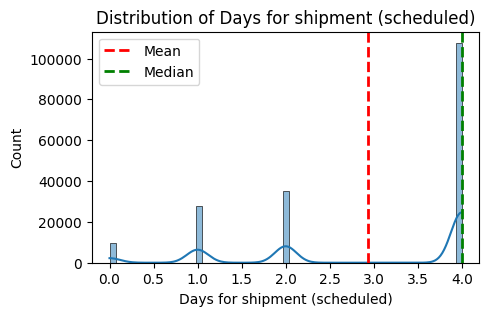

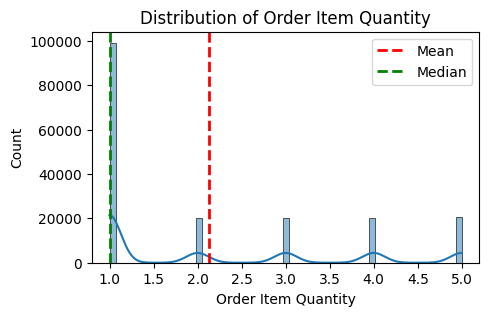

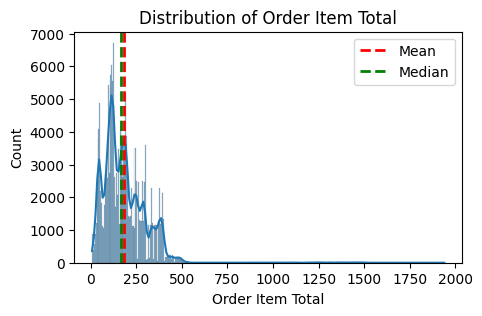

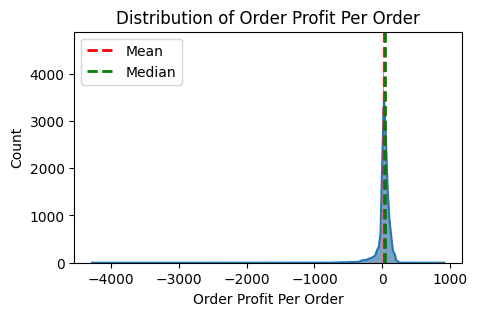

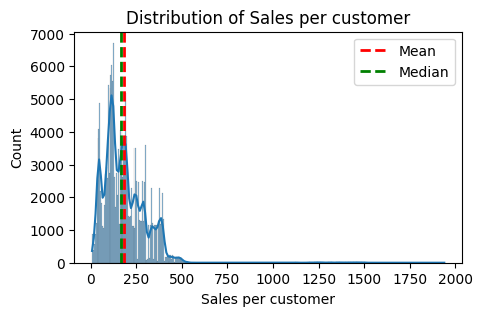

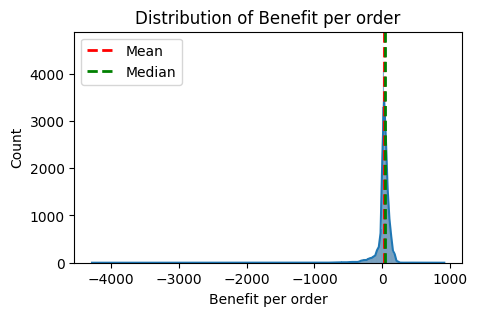

In [13]:
### 4. EDA

#numerical features analysis
numerical_features = ['Days for shipment (scheduled)', 'Order Item Quantity',
                      'Order Item Total', 'Order Profit Per Order',
                      'Sales per customer', 'Benefit per order']

def plot_histogram(df, column_name):
    plt.figure(figsize=(5,3))
    sns.histplot(data=df, x=column_name, kde=True)
    plt.title(f"Distribution of {column_name}")

    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    plt.axvline(col_mean, color="red", linestyle="dashed", linewidth=2, label="Mean")
    plt.axvline(col_median, color="green", linestyle="dashed", linewidth=2, label="Median")
    plt.legend()
    plt.show()

for col in numerical_features:
    if col in df.columns:
        plot_histogram(df, col)

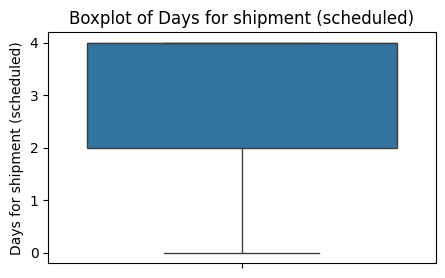

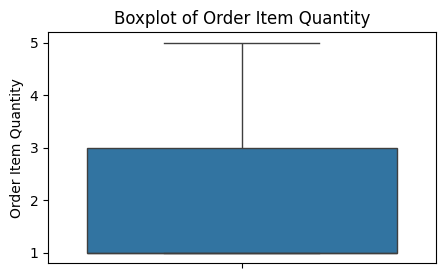

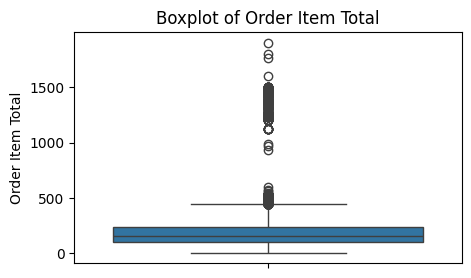

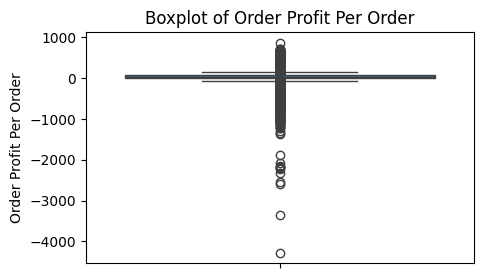

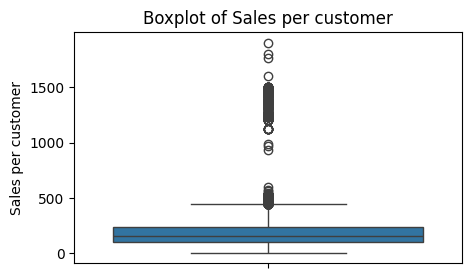

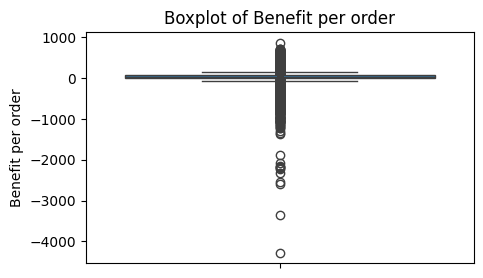

In [18]:
# boxplots to check for outliers
def plot_boxplot(df, column_name):
    plt.figure(figsize=(5,3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Boxplot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

for col in numerical_features:
    if col in df.columns:
        plot_boxplot(df, col)

#here in boxplots the dots represent the ouliers
#for tree based models like XGBoost outliers are not a major concern

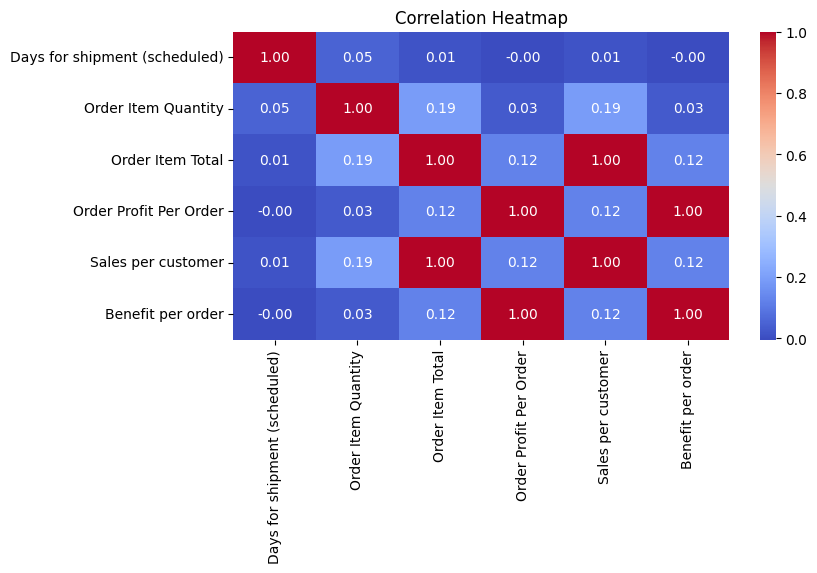

In [19]:
# correlation heatmap for numerical columns
plt.figure(figsize=(8,4))
num_df = df[numerical_features].dropna()
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

['Type', 'Category Name', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Department Name', 'Market', 'Order Region', 'Order Status', 'Product Image', 'Product Name', 'Shipping Mode']


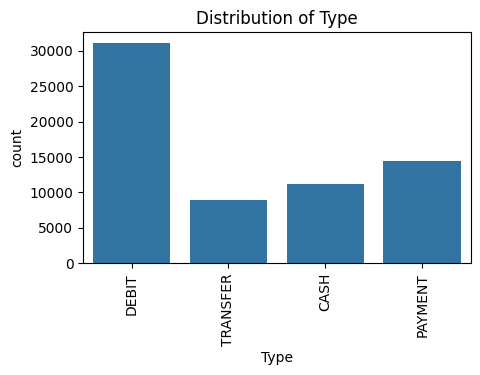

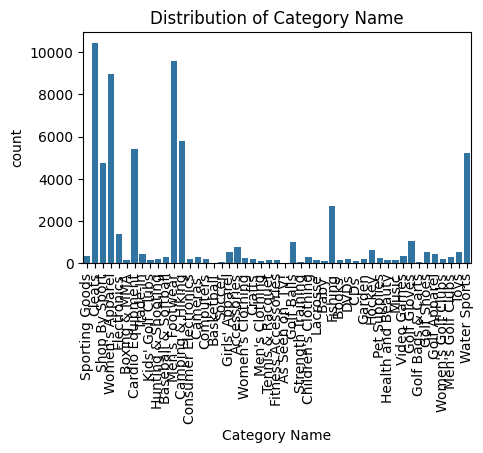

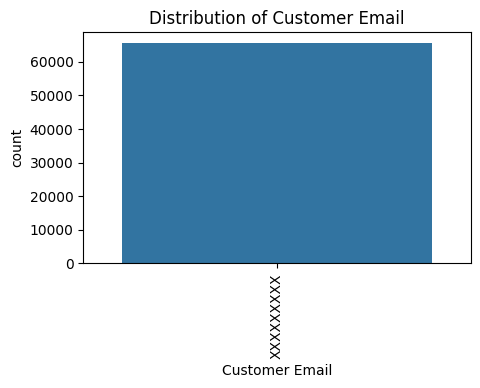

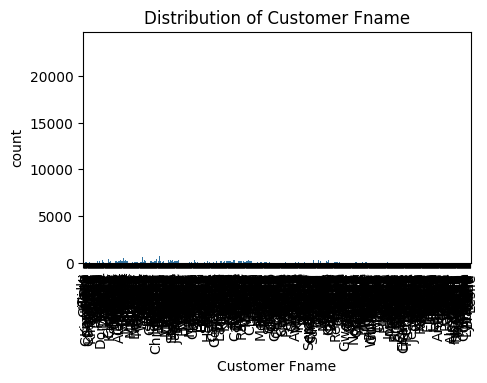

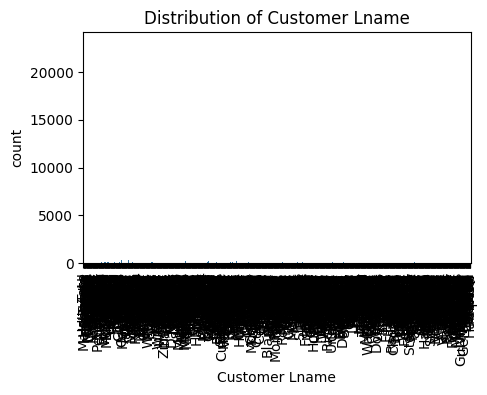

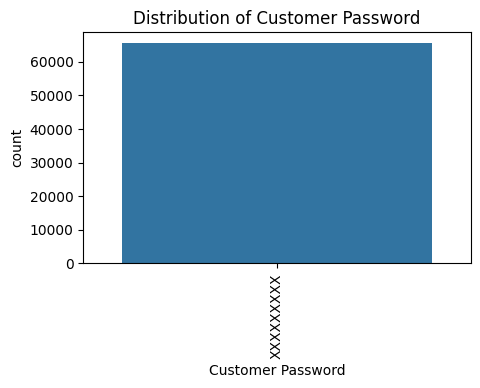

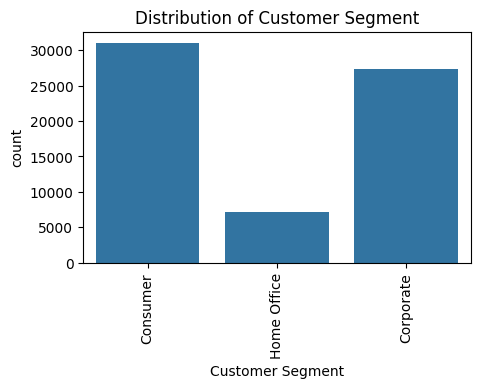

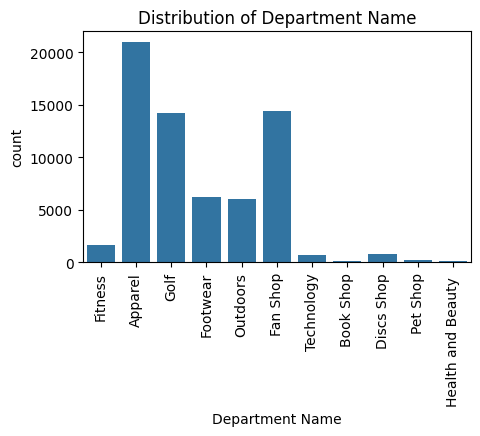

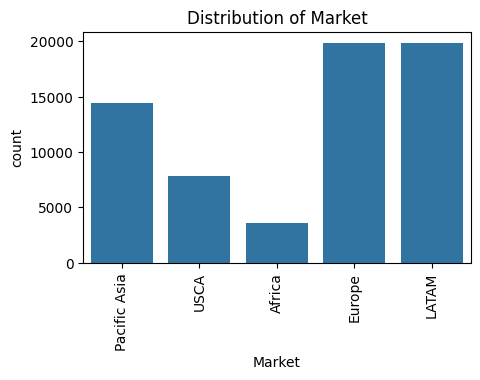

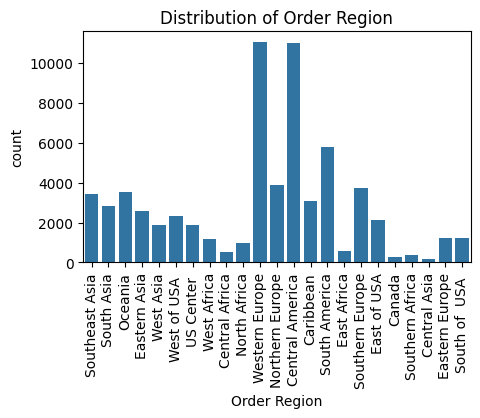

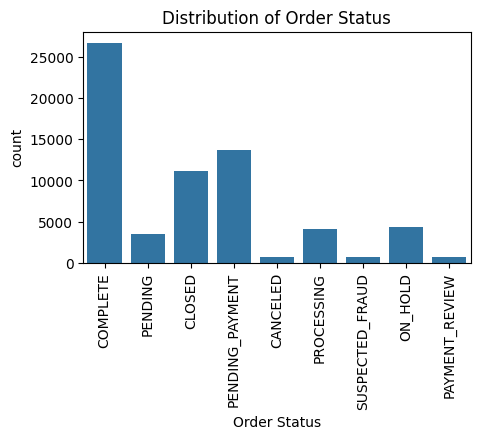

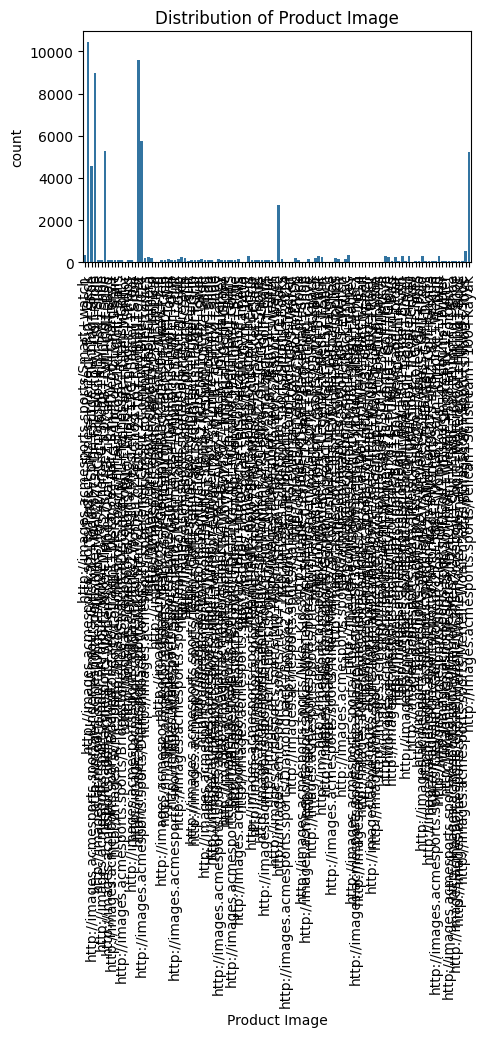

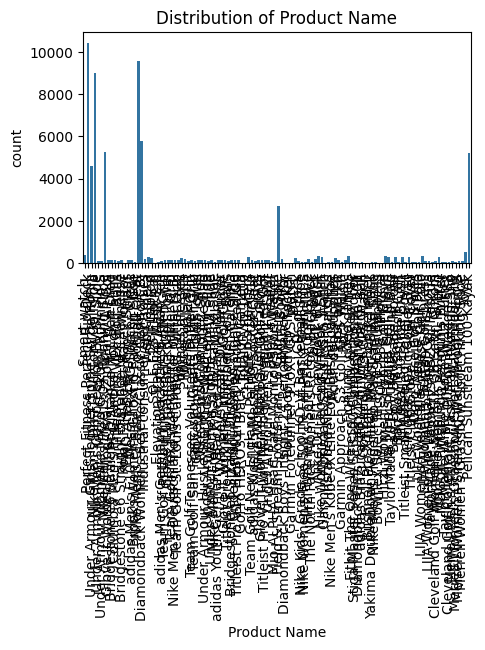

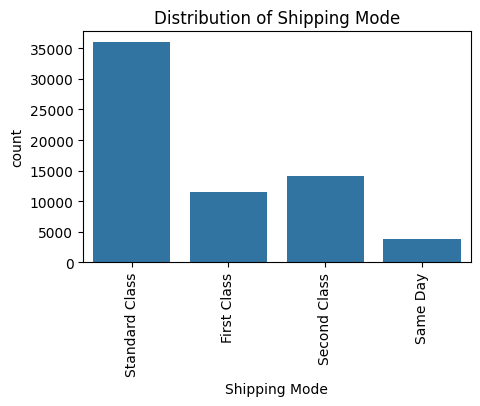

In [20]:
# categorical features distribution
object_cols = df.select_dtypes(include="object").columns.tolist()
print(object_cols)

for col in object_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=90)
    plt.show()

In [21]:
### 5. DATA PREPROCESSING
df.head(3)

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Name,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Department Name,Market,Order Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order Status,Order Zipcode,Product Description,Product Image,Product Name,Product Price,Product Status,Shipping Mode
0,DEBIT,4,91.250000,314.640015,0.0,Sporting Goods,XXXXXXXXX,Cally,20755.0,Holloway,XXXXXXXXX,Consumer,Fitness,Pacific Asia,77202.0,13.110000,0.04,327.75,0.29,1.0,327.75,314.640015,91.250000,Southeast Asia,COMPLETE,NaN,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,Standard Class
1,TRANSFER,4,-249.089996,311.359985,1.0,Sporting Goods,XXXXXXXXX,Irene,19492.0,Luna,XXXXXXXXX,Consumer,Fitness,Pacific Asia,75939.0,16.389999,0.05,327.75,-0.80,1.0,327.75,311.359985,-249.089996,South Asia,PENDING,NaN,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,Standard Class
2,CASH,4,-247.779999,309.720001,0.0,Sporting Goods,XXXXXXXXX,Gillian,19491.0,Maldonado,XXXXXXXXX,Consumer,Fitness,Pacific Asia,75938.0,18.030001,0.06,327.75,-0.80,1.0,327.75,309.720001,-247.779999,South Asia,CLOSED,NaN,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0.0,Standard Class


In [14]:
df.isnull().sum()

,0
Type,0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Late_delivery_risk,0
Category Name,0
Customer Segment,0
Department Name,0
Market,0
Order Item Discount,0


In [15]:
#no nulls remaining confirmed above
df.shape

(180519, 23)

In [16]:
### 6. LABEL ENCODING

print(df["Late_delivery_risk"].value_counts())

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


In [17]:
#identifying object columns
object_cols = df.select_dtypes(include="object").columns
print(object_cols)

Index(['Type', 'Category Name', 'Customer Segment', 'Department Name',
       'Market', 'Order Region', 'Order Status', 'Product Name',
       'Shipping Mode'],
      dtype='object')


In [18]:
import pickle
from sklearn.preprocessing import LabelEncoder

In [19]:
encoders = {}

#apply label encoding and store encoders
for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


In [20]:
 #saving encoders to pickle file
with open("encoders_delivery.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Encoders saved successfully")

df.head()

Encoders saved successfully


,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Name,Customer Segment,Department Name,Market,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,Product Status,Shipping Mode
0,1,4,91.250000,314.640015,0,40,0,4,3,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,15,2,78,327.75,0,3
1,3,4,-249.089996,311.359985,1,40,0,4,3,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,13,5,78,327.75,0,3
2,0,4,-247.779999,309.720001,0,40,0,4,3,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,13,1,78,327.75,0,3
3,1,4,22.860001,304.809998,0,40,2,4,3,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,11,2,78,327.75,0,3
4,2,4,134.210007,298.250000,0,40,1,4,3,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,11,6,78,327.75,0,3


In [21]:
### 7. TRAINING AND TEST DATA SPLIT

# splitting features and target
x = df.drop(columns=["Late_delivery_risk"])
y = df["Late_delivery_risk"]

print("Features shape:", x.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (180519, 22)
Target distribution:
 Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

print("Train size:", x_train.shape)
print("Test size:", x_test.shape)

Train size: (144415, 22)
Test size: (36104, 22)


In [23]:
print("\nTrain target distribution:\n", y_train.value_counts())


Train target distribution:
 Late_delivery_risk
1    79180
0    65235
Name: count, dtype: int64


In [24]:
### 8. MODEL TRAINING

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [25]:
cv_scores = {}

#performing 5-fold cross validation in each model
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring="accuracy")
    cv_scores[model_name] = scores
    print(f"{model_name} cross-validation: {np.mean(scores):.2f}")

cv_scores

Training Logistic Regression with default parameters


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression cross-validation: 0.68
Training Random Forest with default parameters
Random Forest cross-validation: 0.68
Training XGBoost with default parameters
XGBoost cross-validation: 0.71


{'Logistic Regression': array([0.67839213, 0.68403559, 0.68905585, 0.67641865, 0.69231036]),
 'Random Forest': array([0.68375861, 0.68043486, 0.68351626, 0.68566285, 0.68514351]),
 'XGBoost': array([0.70757885, 0.69937333, 0.70602084, 0.70588235, 0.70775196])}

In [26]:
#XGBoost gives the highest cross validation accuracy

#train all 3 models
trained_models = {}

for model_name, model in models.items():
    model.fit(x_train, y_train)
    trained_models[model_name] = model

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
for model_name, model in trained_models.items():
    print(f"{model_name} Report:")
    y_pred = model.predict(x_test)
    print(classification_report(y_test, y_pred))
    print(f"Train Accuracy: {model.score(x_train, y_train):.4f}")
    print(f"Test Accuracy: {model.score(x_test, y_test):.4f}")


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.61      0.80      0.69     16307
           1       0.78      0.58      0.67     19797

    accuracy                           0.68     36104
   macro avg       0.69      0.69      0.68     36104
weighted avg       0.70      0.68      0.68     36104

Train Accuracy: 0.6829
Test Accuracy: 0.6795
Random Forest Report:
              precision    recall  f1-score   support

           0       0.63      0.72      0.67     16307
           1       0.74      0.65      0.69     19797

    accuracy                           0.68     36104
   macro avg       0.68      0.68      0.68     36104
weighted avg       0.69      0.68      0.68     36104

Train Accuracy: 0.9961
Test Accuracy: 0.6804
XGBoost Report:
              precision    recall  f1-score   support

           0       0.63      0.87      0.73     16307
           1       0.84      0.57      0.68     19797

    accuracy              

## Observation
Logistic Regression: No overfitting but lowest accuracy
Random Forest: Severe overfitting (31.6% gap) —
memorized training data completely
XGBoost: Best balance — only 3% gap with highest
test accuracy of 70%
XGBoost selected for hyperparameter tuning

In [28]:
### 10. HYPERPARAMETER TUNING

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1]
}

In [29]:
grid = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best F1:", grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best F1: 0.7055904143197905


In [30]:
#model evaluation after hyperparameter tuning
y_pred_tuned = best_model.predict(x_test)

print("\nAfter Hyperparameter Tuning:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_tuned, average='weighted'))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))


After Hyperparameter Tuning:
Accuracy: 0.7061267449590073
F1 Score: 0.7028076121433404
Recall: 0.7061267449590073

Confusion Matrix:
 [[13978  2329]
 [ 8281 11516]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.86      0.72     16307
           1       0.83      0.58      0.68     19797

    accuracy                           0.71     36104
   macro avg       0.73      0.72      0.70     36104
weighted avg       0.74      0.71      0.70     36104



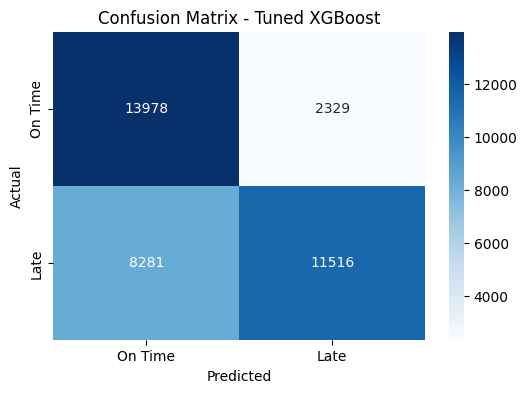

In [31]:
# confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'])
plt.title('Confusion Matrix - Tuned XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

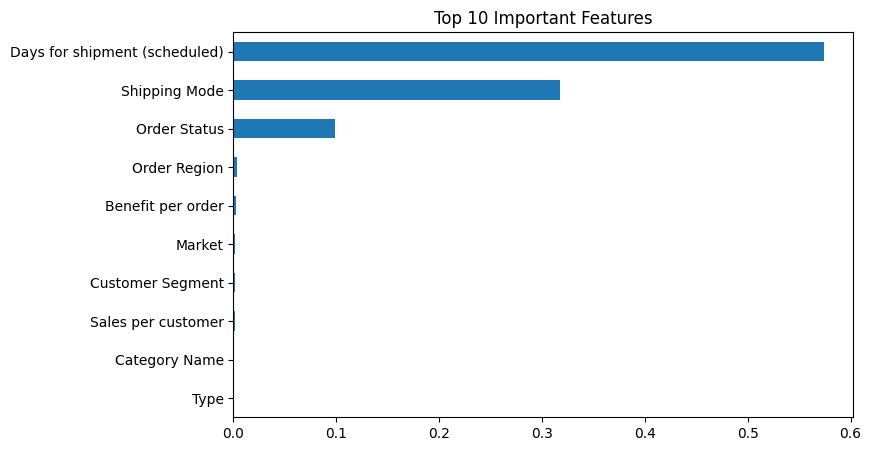

In [32]:
#feature importance
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)[:10]

plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh')
plt.title('Top 10 Important Features')
plt.gca().invert_yaxis()
plt.show()

In [33]:
#before vs after comparison table
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score", "Recall"],
    "Logistic Regression": [0.71, 0.71, 0.73],
    "Random Forest": [0.70, 0.70, 0.70],
    "XGBoost Tuned": [
        round(accuracy_score(y_test, y_pred_tuned), 2),
        round(f1_score(y_test, y_pred_tuned, average='weighted'), 2),
        round(recall_score(y_test, y_pred_tuned, average='weighted'), 2)
    ]
})

print(comparison)

     Metric  Logistic Regression  Random Forest  XGBoost Tuned
0  Accuracy                 0.71            0.7           0.71
1  F1 Score                 0.71            0.7           0.70
2    Recall                 0.73            0.7           0.71


In [34]:
# save the trained tuned model as pickle file
model_data = {
    "model": best_model,
    "features_names": x.columns.tolist()
}

with open("late_delivery_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model saved successfully")

Model saved successfully


In [35]:
### 11. LOAD THE SAVED MODEL AND BUILD A PREDICTIVE SYSTEM

with open("late_delivery_model.pkl", "rb") as f:
    model_data = pickle.load(f)
    loaded_model = model_data["model"]
    features_names = model_data["features_names"]

print("Model loaded successfully")
print("Expected features:", features_names)

Model loaded successfully
Expected features: ['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Category Name', 'Customer Segment', 'Department Name', 'Market', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order Status', 'Product Name', 'Product Price', 'Product Status', 'Shipping Mode']


In [37]:
#build input data, only values known at time of order
data = {
    "Type": "DEBIT",
    "Days for shipment (scheduled)": 4,
    "Benefit per order": 91.25,
    "Sales per customer": 314.64,
    "Category Name": "Cleats",
    "Customer Segment": "Consumer",
    "Department Name": "Fan Shop",
    "Market": "Pacific Asia",
    "Order Item Discount": 0.0,
    "Order Item Discount Rate": 0.0,
    "Order Item Product Price": 59.99,
    "Order Item Profit Ratio": 0.36,
    "Order Item Quantity": 3,
    "Sales": 209.964,
    "Order Item Total": 209.964,
    "Order Profit Per Order": 74.628,
    "Order Region": "Southeast Asia",
    "Order Status": "PENDING",
    "Product Name": "Nike Men's Hypervenom Phantom Premium FG Soccer Cleat",
    "Product Price": 59.99,
    "Product Status": 0,
    "Shipping Mode": "Standard Class"
}

data_df = pd.DataFrame([data])
print(data_df)

    Type  Days for shipment (scheduled)  Benefit per order  \
0  DEBIT                              4              91.25   

   Sales per customer Category Name Customer Segment Department Name  \
0              314.64        Cleats         Consumer        Fan Shop   

         Market  Order Item Discount  Order Item Discount Rate  \
0  Pacific Asia                  0.0                       0.0   

   Order Item Product Price  Order Item Profit Ratio  Order Item Quantity  \
0                     59.99                     0.36                    3   

     Sales  Order Item Total  Order Profit Per Order    Order Region  \
0  209.964           209.964                  74.628  Southeast Asia   

  Order Status                                       Product Name  \
0      PENDING  Nike Men's Hypervenom Phantom Premium FG Socce...   

   Product Price  Product Status   Shipping Mode  
0          59.99               0  Standard Class  


In [38]:
#loading encoders and apply them
with open("encoders_delivery.pkl", "rb") as f:
    encoders = pickle.load(f)

In [40]:
# handle any missing columns
for col in features_names:
    if col not in data_df.columns:
        if col in encoders:
            data_df[col] = encoders[col].classes_[0]
        else:
            data_df[col] = 0

#convert to string then apply encoders
for col, encoder in encoders.items():
    if col in data_df.columns:
        #Convert to string first to handle mixed types if there is any
        data_df[col] = data_df[col].astype(str)

        # Identify unseen labels in the current column
        unseen_labels_mask = ~data_df[col].isin(encoder.classes_)

        if unseen_labels_mask.any():
            #Replace unseen labels with the first class of the encoder

            data_df.loc[unseen_labels_mask, col] = encoder.classes_[0]

        data_df[col] = encoder.transform(data_df[col])

In [41]:
# reorder columns to match training
data_df = data_df[features_names]

print("Input data after encoding:")
print(data_df)

Input data after encoding:
   Type  Days for shipment (scheduled)  Benefit per order  Sales per customer  \
0     0                              4              91.25              314.64   

   Category Name  Customer Segment  Department Name  Market  \
0              0                 0                0       0   

   Order Item Discount  Order Item Discount Rate  Order Item Product Price  \
0                  0.0                       0.0                     59.99   

   Order Item Profit Ratio  Order Item Quantity    Sales  Order Item Total  \
0                     0.36                    3  209.964           209.964   

   Order Profit Per Order  Order Region  Order Status  Product Name  \
0                  74.628             0             0             0   

   Product Price  Product Status  Shipping Mode  
0          59.99               0              3  


In [42]:
#final prediction
prediction = loaded_model.predict(data_df)
pred_prob = loaded_model.predict_proba(data_df)

print(f"\nPrediction: {'Late Delivery' if prediction[0] == 1 else 'On Time'}")
print(f"Late Delivery Probability: {pred_prob[0][1]:.2%}")
print(f"On Time Probability: {pred_prob[0][0]:.2%}")


Prediction: On Time
Late Delivery Probability: 1.29%
On Time Probability: 98.71%
